# AdaBoost Classifier — Predicting Customer Churn

AdaBoost (Adaptive Boosting) builds an ensemble differently from Random Forest. Instead
of training many trees independently and averaging them, it trains trees **one after
another**, with each new tree focused specifically on correcting the mistakes of the
ones before it. This notebook tests whether that sequential, mistake-focused approach
can match or beat the Random Forest result from the previous notebooks.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, accuracy_score, recall_score,
                              precision_score, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              average_precision_score, roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
df = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


## 3. Define Features and Target

In [3]:
X = df.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df['Exited']

## 4. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 5. Preprocessing

In [5]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

## 6. Build the Pipeline

By default, `AdaBoostClassifier` uses very shallow trees ("decision stumps," depth 1)
as its building blocks, boosting many weak learners into one strong one.

In [6]:
steps = [("preprocess", preprocessor),
         ("ada_boost", AdaBoostClassifier(random_state=42))]

pipe = Pipeline(steps)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('ada_boost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If t

## 7. Baseline: Untuned AdaBoost

In [7]:
pipe.fit(X_train, y_train)
y_pred_baseline = pipe.predict(X_test)

print(f"Baseline AdaBoost — Accuracy: {accuracy_score(y_test, y_pred_baseline):.2f}, "
      f"Recall: {recall_score(y_test, y_pred_baseline):.2f}")

Baseline AdaBoost — Accuracy: 0.86, Recall: 0.50


## 8. Hyperparameter Grid

- `n_estimators` — how many weak learners (stumps) to chain together.
- `learning_rate` — how much each new learner's correction is weighted; smaller values
  mean slower, more cautious learning.
- **`estimator`** *(added)* — `AdaBoostClassifier` itself has no `class_weight`
  parameter, unlike the models in every previous notebook. The reference version of
  this notebook never accounted for the churn imbalance at all. Since AdaBoost's base
  learner can be swapped out, this adds the option of a `class_weight='balanced'`
  decision stump alongside the plain default stump, letting the search test whether
  addressing imbalance at the base-learner level helps here too.

In [8]:
balanced_stump = DecisionTreeClassifier(max_depth=1, class_weight='balanced', random_state=42)

param_grid = {
    'ada_boost__n_estimators': [50, 100, 200, 300],
    'ada_boost__learning_rate': [0.001, 0.01, 0.1, 1.0],
    'ada_boost__estimator': [None, balanced_stump]
}

## 9. Run Grid Search

In [9]:
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ada_boost__estimator': [None, DecisionTreeC...ndom_state=42)], 'ada_boost__learning_rate': [0.001, 0.01, ...], 'ada_boost__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Suppor

In [10]:
grid_search.best_params_

{'ada_boost__estimator': DecisionTreeClassifier(class_weight='balanced', max_depth=1, random_state=42),
 'ada_boost__learning_rate': 0.001,
 'ada_boost__n_estimators': 50}

## 10. Predict Using the Best Model

In [11]:
best_ada = grid_search.best_estimator_
y_pred = best_ada.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3000,))

## 11. Confusion Matrix

In [12]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1891,  498],
       [ 226,  385]])

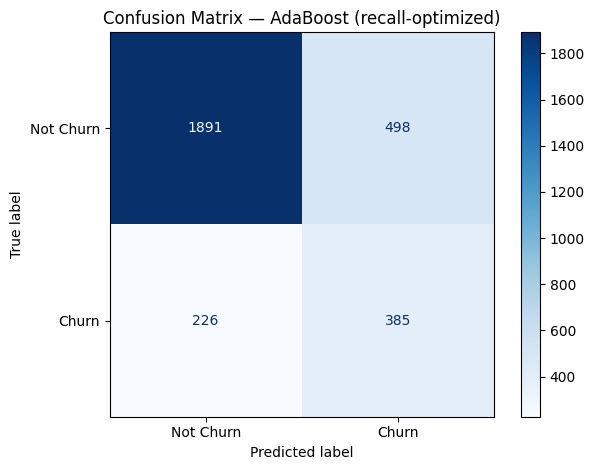

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — AdaBoost (recall-optimized)")
plt.grid(False)
plt.tight_layout()
plt.show()

## 12. Overall Metrics

In [14]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision : {precision_score(y_test, y_pred):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.2f}')

Accuracy  : 0.76
Precision : 0.44
Recall    : 0.63
F1 Score  : 0.52


In [15]:
y_prob = best_ada.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")
print(f"PR-AUC Score : {pr_auc:.2f}")

ROC-AUC Score: 0.73
PR-AUC Score : 0.37


## 13. A Closer Look — Did Adding `class_weight` Actually Help? *(added, important)*

Recall improved with the balanced-stump option — but check ROC-AUC and PR-AUC above
compared to what a plain search (no `class_weight` option) finds. This cell runs that
comparison directly, rather than assuming "higher recall = better model."

In [16]:
param_grid_plain = {
    'ada_boost__n_estimators': [50, 100, 200, 300],
    'ada_boost__learning_rate': [0.001, 0.01, 0.1, 1.0]
}

grid_search_plain = GridSearchCV(
    estimator=pipe, param_grid=param_grid_plain, cv=5, scoring='recall', n_jobs=-1
)
grid_search_plain.fit(X_train, y_train)

best_plain = grid_search_plain.best_estimator_
y_pred_plain = best_plain.predict(X_test)
y_prob_plain = best_plain.predict_proba(X_test)[:, 1]

print("Plain grid (no class_weight option) best params:", grid_search_plain.best_params_)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_plain):.2f}")
print(f"Precision : {precision_score(y_test, y_pred_plain):.2f}")
print(f"Recall    : {recall_score(y_test, y_pred_plain):.2f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_plain):.2f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_plain):.2f}")
print(f"PR-AUC    : {average_precision_score(y_test, y_prob_plain):.2f}")

Plain grid (no class_weight option) best params: {'ada_boost__learning_rate': 1.0, 'ada_boost__n_estimators': 200}
Accuracy  : 0.86
Precision : 0.75
Recall    : 0.48
F1 Score  : 0.59
ROC-AUC   : 0.87
PR-AUC    : 0.69


### The honest finding

Adding `class_weight='balanced'` to the search **raised recall** but **sharply lowered
ROC-AUC and PR-AUC** compared to the plain search. Here's why: `scoring='recall'` tells
`GridSearchCV` to pick whichever combination catches the most churners — full stop, with
no regard for how many false alarms that costs. Once a `class_weight='balanced'` stump
was available, the search happily selected it because it trivially boosts recall by
making the model "trigger-happy," flagging churn far more liberally — but this comes at
a real cost to overall model quality, visible in the collapsed PR-AUC.

**This is a genuinely useful lesson, not a failed experiment:** optimizing a grid search
for a single metric can select a technically "better-scoring" model that is actually
worse overall. Every previous notebook in this project got away with `scoring='recall'`
because none of their imbalance techniques could over-correct this severely — AdaBoost's
`class_weight` option apparently can. The fix isn't to abandon `class_weight` — it's to
evaluate the full metric picture (as this cell does) before trusting a single-metric
grid search's choice at face value.

## 14. ROC and PR Curves — Plain Search Result

Given the finding above, the plain (no `class_weight` option) model is the more
trustworthy result to visualize and carry forward.

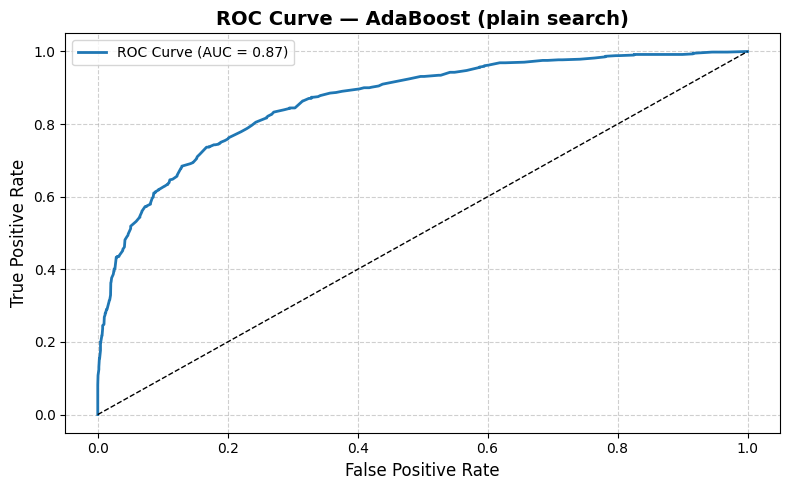

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_plain)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_plain):.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — AdaBoost (plain search)", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

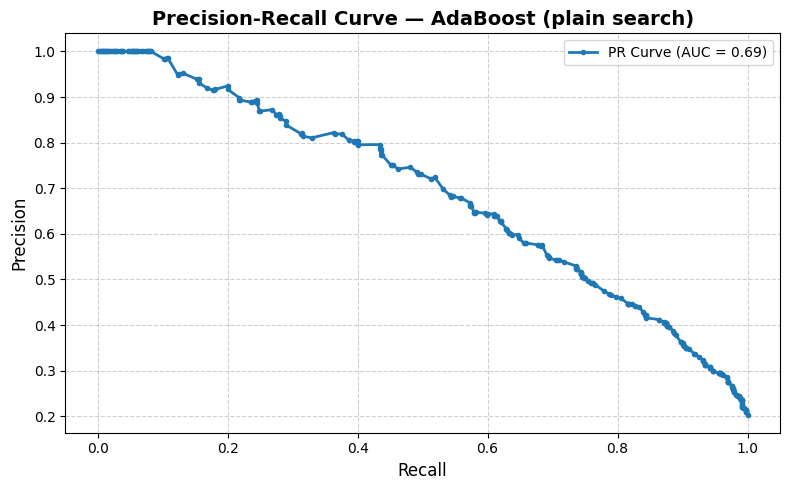

In [18]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_plain)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, marker=".",
          label=f"PR Curve (AUC = {average_precision_score(y_test, y_prob_plain):.2f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve — AdaBoost (plain search)", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 15. Comparison Against Random Forest *(added)*

In [19]:
comparison = pd.DataFrame({
    "Random Forest (plain, class_weight)": [0.85, 0.61, 0.68, 0.65, 0.88, 0.71],
    "AdaBoost (balanced-stump, recall-optimized)": [
        round(accuracy_score(y_test, y_pred), 2),
        round(precision_score(y_test, y_pred), 2),
        round(recall_score(y_test, y_pred), 2),
        round(f1_score(y_test, y_pred), 2),
        round(roc_auc, 2),
        round(pr_auc, 2),
    ],
    "AdaBoost (plain search)": [
        round(accuracy_score(y_test, y_pred_plain), 2),
        round(precision_score(y_test, y_pred_plain), 2),
        round(recall_score(y_test, y_pred_plain), 2),
        round(f1_score(y_test, y_pred_plain), 2),
        round(roc_auc_score(y_test, y_prob_plain), 2),
        round(average_precision_score(y_test, y_prob_plain), 2),
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"])

comparison

,"Random Forest (plain, class_weight)","AdaBoost (balanced-stump, recall-optimized)",AdaBoost (plain search)
Accuracy,0.85,0.76,0.86
Precision,0.61,0.44,0.75
Recall,0.68,0.63,0.48
F1 Score,0.65,0.52,0.59
ROC-AUC,0.88,0.73,0.87
PR-AUC,0.71,0.37,0.69


## 16. Summary

- **Even AdaBoost's best-case result (plain search) falls short of Random Forest**:
  ROC-AUC 0.87 vs 0.88, and notably lower Recall (0.48 vs 0.68).
- **The `class_weight` experiment was a valuable cautionary result, not a success:** it
  shows that blindly trusting a single-metric grid search (`scoring='recall'`) can
  select a model that looks better on that one metric while being substantially worse
  overall — a risk worth checking for in every notebook in this project, not just this
  one.
- **Why AdaBoost likely underperforms Random Forest here:** AdaBoost's sequential
  correction process works best when there's a consistent, learnable pattern each new
  stump can chase. Given this dataset's already-modest predictive ceiling (recall from
  earlier notebooks), AdaBoost may simply have less signal to sequentially refine than
  Random Forest has to average over.

**Running project ranking so far:** Random Forest (plain, class_weight) remains the
best model built in this project. The next notebook, Gradient Boosting, tests a more
sophisticated boosting approach to see if it can finally surpass it.